# Targeted finetune learning-curve analysis: random split (Apr 3/4 2026)

This notebook analyzes the finished random-split rerun in `lib1_enhancer_targeted_random_all_per_seed_apr2026`.

Run command:
```bash
CUDA_VISIBLE_DEVICES=0 python boda2_EU/src/finetune/finetune_sweep_scripts/lib1_enhancer_learning_curve_finetune_split_options.py --outdir /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_targeted_random_all_per_seed_apr2026 --split_strategy random_all_per_seed --split_seed 7 --val_frac 0.15 --test_frac 0.15 --include_b2 --include_b3 --b3_bcaps 8 10 --train_thresholds 1 --unfreeze_scopes branched_only conv3_plus full --head_lrs 2e-4 5e-4 --backbone_lrs 1e-5 1e-4 --train_size_fracs 0.05 0.1 0.2 0.35 0.5 0.75 1.0 --train_sampling_mode random --seeds 17 23 19 31
```

Main goals:
- reuse the most informative learning-curve views from the earlier targeted notebook "boda2_EU/tutorials/lib1_tasks/fine_tuning/`targeted_finetune_learning_curve_HQ_split_apr1_2026.ipynb`"
- keep the double-y `R2` plus `best_epoch` plot,
- check whether the earlier B2/B3 patterns remain visible when validation and test splits vary by seed,
- inspect how random sampling changes the HQ fraction across train sizes,
- estimate where additional samples still appear to buy measurable test-set gain.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

RUN_DIR = Path(
    "/home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/"
    "lib1_enhancer_targeted_random_all_per_seed_apr2026"
)

zero_shot = pd.read_csv(RUN_DIR / "zero_shot_by_seed.csv")
runs = pd.read_csv(RUN_DIR / "learning_curve_runs.csv")
histories = pd.read_csv(RUN_DIR / "learning_curve_histories.csv")
summary = pd.read_csv(RUN_DIR / "learning_curve_summary_mean_std.csv")
scope_summary = pd.read_csv(RUN_DIR / "unfreeze_scope_summary_mean_std.csv")

with open(RUN_DIR / "run_manifest.json", "r") as f:
    manifest = json.load(f)

print("RUN_DIR:", RUN_DIR)
print("zero_shot:", zero_shot.shape)
print("runs:", runs.shape)
print("histories:", histories.shape)
print("summary:", summary.shape)
print("scope_summary:", scope_summary.shape)

RUN_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_targeted_random_all_per_seed_apr2026
zero_shot: (12, 12)
runs: (3024, 81)
histories: (80359, 36)
summary: (756, 90)
scope_summary: (36, 39)


In [2]:
def _manifest_value(value):
    if isinstance(value, (list, dict)):
        return json.dumps(value)
    return value

manifest_keys = [
    "run_id",
    "run_started_at",
    "device_resolved",
    "split_strategy",
    "train_sampling_mode",
    "train_thresholds",
    "train_size_fracs",
    "val_frac",
    "test_frac",
    "head_lrs",
    "backbone_lrs",
    "b3_bcaps",
]
manifest_df = pd.DataFrame(
    {
        "manifest_key": manifest_keys,
        "value": [_manifest_value(manifest.get(key)) for key in manifest_keys],
    }
)
display(manifest_df)

scope_order = ["branched_only", "conv3_plus", "full"]
train_size_order = sorted(runs["train_size"].unique().tolist())
SETTING_LABEL_MAP = {
    "B2_with_RC": "B2_RC",
    "B3_with_RC_weighted_bcap_8": "B3_RC_bcap_8",
    "B3_with_RC_weighted_bcap_10": "B3_RC_bcap_10",
}
setting_order = [
    SETTING_LABEL_MAP["B2_with_RC"],
    SETTING_LABEL_MAP["B3_with_RC_weighted_bcap_8"],
    SETTING_LABEL_MAP["B3_with_RC_weighted_bcap_10"],
]

for frame in (runs, histories, summary, scope_summary):
    frame["setting_label"] = frame["setting"].map(SETTING_LABEL_MAP).fillna(frame["setting"])

print("Settings:", sorted(runs["setting"].unique().tolist()))
print("Init heads:", sorted(runs["init_head"].unique().tolist()))
print("Seeds:", sorted(runs["seed"].unique().tolist()))
print("Unfreeze scopes:", sorted(runs["unfreeze_scope"].unique().tolist()))
print("Train sizes:", train_size_order)

,manifest_key,value
0,run_id,20260404T012757Z_c5d4eba0
1,run_started_at,2026-04-04T01:27:57.924181+00:00
2,device_resolved,cuda
3,split_strategy,random_all_per_seed
4,train_sampling_mode,random
5,train_thresholds,[1]
6,train_size_fracs,"[0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]"
7,val_frac,0.15
8,test_frac,0.15
9,head_lrs,"[0.0002, 0.0005]"


Settings: ['B2_with_RC', 'B3_with_RC_weighted_bcap_10', 'B3_with_RC_weighted_bcap_8']
Init heads: ['HepG2', 'K562', 'SKNSH']
Seeds: [17, 19, 23, 31]
Unfreeze scopes: ['branched_only', 'conv3_plus', 'full']
Train sizes: [134, 268, 536, 938, 1340, 2011, 2681]


## Select one HPO per setting and scope

As in the earlier targeted analysis, the notebook picks a single HPO point for each `setting x unfreeze_scope` combination by ranking the largest-train-size results with:

1. mean validation `R2`
2. mean test `R2`
3. mean validation loss

That keeps the learning-curve comparisons compact while still using the random-split rerun to test robustness across seeds.

In [3]:
thr1_summary = summary.query("train_threshold == 1").copy()
full_train_size = int(thr1_summary["train_size"].max())
selection_keys = ["setting", "unfreeze_scope", "head_lr", "backbone_lr"]

full_train_grid = (
    thr1_summary[thr1_summary["train_size"] == full_train_size]
    .groupby(selection_keys, dropna=False)
    .agg(
        mean_val_r2=("val_r2_mean", "mean"),
        mean_test_r2=("test_r2_mean", "mean"),
        mean_val_loss=("val_loss_standardized_mean", "mean"),
        mean_test_loss=("test_loss_standardized_mean", "mean"),
        mean_best_epoch=("best_epoch_mean", "mean"),
        n_rows=("val_r2_mean", "size"),
    )
    .reset_index()
)

best_hpo = (
    full_train_grid
    .sort_values(
        ["setting", "unfreeze_scope", "mean_val_r2", "mean_test_r2", "mean_val_loss"],
        ascending=[True, True, False, False, True],
    )
    .drop_duplicates(["setting", "unfreeze_scope"])
    .sort_values(["setting", "unfreeze_scope"])
    .reset_index(drop=True)
)
best_hpo["setting_label"] = best_hpo["setting"].map(SETTING_LABEL_MAP).fillna(best_hpo["setting"])

print(f"Selecting one HPO point per setting/scope using full-train-size val R2 at n={full_train_size}.")
display(best_hpo)

Selecting one HPO point per setting/scope using full-train-size val R2 at n=2681.


,setting,unfreeze_scope,head_lr,backbone_lr,mean_val_r2,mean_test_r2,mean_val_loss,mean_test_loss,mean_best_epoch,n_rows,setting_label
0,B2_with_RC,branched_only,0.0005,0.00001,0.152174,0.102447,0.887795,0.864280,19.500000,3,B2_RC
1,B2_with_RC,conv3_plus,0.0005,0.00001,0.151027,0.095621,0.888754,0.870735,9.583333,3,B2_RC
2,B2_with_RC,full,0.0005,0.00001,0.146731,0.095254,0.893181,0.870931,5.833333,3,B2_RC
3,B3_with_RC_weighted_bcap_10,branched_only,0.0005,0.00001,0.148514,0.097935,0.891778,0.868297,15.833333,3,B3_RC_bcap_10
4,B3_with_RC_weighted_bcap_10,conv3_plus,0.0005,0.00001,0.148976,0.092737,0.891112,0.873215,10.750000,3,B3_RC_bcap_10
5,B3_with_RC_weighted_bcap_10,full,0.0005,0.00001,0.145472,0.095397,0.894717,0.870639,5.333333,3,B3_RC_bcap_10
6,B3_with_RC_weighted_bcap_8,branched_only,0.0002,0.00001,0.148532,0.097810,0.891599,0.868385,32.000000,3,B3_RC_bcap_8
7,B3_with_RC_weighted_bcap_8,conv3_plus,0.0005,0.00001,0.148762,0.092362,0.891326,0.873568,10.416667,3,B3_RC_bcap_8
8,B3_with_RC_weighted_bcap_8,full,0.0005,0.00001,0.145563,0.095655,0.894607,0.870401,5.166667,3,B3_RC_bcap_8


In [4]:
best_keys = selection_keys

best_runs = runs.merge(best_hpo[best_keys], on=best_keys, how="inner")
best_histories = histories.merge(best_hpo[best_keys], on=best_keys, how="inner")
best_summary = summary.merge(best_hpo[best_keys], on=best_keys, how="inner")

for frame in (best_runs, best_histories, best_summary):
    frame["setting_label"] = frame["setting"].map(SETTING_LABEL_MAP).fillna(frame["setting"])

print("best_runs:", best_runs.shape)
print("best_histories:", best_histories.shape)
print("best_summary:", best_summary.shape)

coverage = (
    best_runs.groupby(["setting_label", "unfreeze_scope"], dropna=False)
    .agg(
        n_runs=("run_id", "nunique"),
        n_heads=("init_head", "nunique"),
        n_seeds=("seed", "nunique"),
        n_train_sizes=("train_size", "nunique"),
    )
    .reset_index()
    .sort_values(["setting_label", "unfreeze_scope"])
)
display(coverage)

zero_shot_summary = (
    zero_shot.groupby("init_head", dropna=False)
    .agg(
        zero_shot_r2_mean=("r2", "mean"),
        zero_shot_r2_std=("r2", "std"),
        zero_shot_pearson_mean=("pearson", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)
display(zero_shot_summary)

best_runs: (756, 82)
best_histories: (20109, 37)
best_summary: (189, 91)


,setting_label,unfreeze_scope,n_runs,n_heads,n_seeds,n_train_sizes
0,B2_RC,branched_only,1,3,4,7
1,B2_RC,conv3_plus,1,3,4,7
2,B2_RC,full,1,3,4,7
3,B3_RC_bcap_10,branched_only,1,3,4,7
4,B3_RC_bcap_10,conv3_plus,1,3,4,7
5,B3_RC_bcap_10,full,1,3,4,7
6,B3_RC_bcap_8,branched_only,1,3,4,7
7,B3_RC_bcap_8,conv3_plus,1,3,4,7
8,B3_RC_bcap_8,full,1,3,4,7


,init_head,zero_shot_r2_mean,zero_shot_r2_std,zero_shot_pearson_mean,n_seeds
0,HepG2,-9.615281,0.396759,0.215589,4
1,K562,-9.535904,0.429177,0.233220,4
2,SKNSH,-10.456347,0.545667,0.215138,4


In [5]:
def plot_dual_axis_curves(frame):
    summary_plot_df = (
        frame.groupby(["setting_label", "unfreeze_scope", "train_size"], dropna=False)
        .agg(
            train_r2_mean=("train_r2", "mean"),
            val_r2_mean=("val_r2", "mean"),
            test_r2_mean=("test_r2", "mean"),
            best_epoch_mean=("best_epoch", "mean"),
            train_hq_fraction_mean=("train_hq_fraction", "mean"),
        )
        .reset_index()
    )
    summary_plot_df["setting_label"] = pd.Categorical(
        summary_plot_df["setting_label"], categories=setting_order, ordered=True
    )

    for setting_label in setting_order:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
        setting_df = summary_plot_df[summary_plot_df["setting_label"] == setting_label].copy()
        legend_handles = None
        legend_labels = None

        for ax, scope in zip(axes, scope_order):
            sub = setting_df[setting_df["unfreeze_scope"] == scope].sort_values("train_size")
            if sub.empty:
                ax.set_visible(False)
                continue

            ax.plot(sub["train_size"], sub["train_r2_mean"], marker="o", label="train R2", color="#4c72b0")
            ax.plot(sub["train_size"], sub["val_r2_mean"], marker="o", label="validation R2", color="#dd8452")
            ax.plot(sub["train_size"], sub["test_r2_mean"], marker="o", label="test R2", color="#55a868")
            ax.set_xscale("log")
            ax.set_xlabel("train_size")
            ax.set_ylabel("R2")
            ax.set_title(scope)

            ax2 = ax.twinx()
            ax2.plot(
                sub["train_size"],
                sub["best_epoch_mean"],
                marker="s",
                linestyle=":",
                linewidth=2,
                color="black",
                label="best epoch",
            )
            ax2.set_ylabel("best_epoch")
            ax2.grid(False)

            if legend_handles is None:
                lines1, labels1 = ax.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                legend_handles = lines1 + lines2
                legend_labels = labels1 + labels2

        fig.suptitle(f"{setting_label}: R2 and selected best_epoch vs train size", y=1.06)
        if legend_handles is not None:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.98),
                ncol=len(legend_labels),
                frameon=False,
            )
        fig.text(
            0.995,
            0.01,
            "No single dashed breakpoint here: random sampling mixes HQ and lower-quality examples from the start.",
            ha="right",
            va="bottom",
            fontsize=10,
        )
        fig.tight_layout(rect=[0, 0.05, 1, 0.88])
        plt.show()


def plot_split_metric_curves(frame, metric_root, y_label):
    split_map = {
        f"train_{metric_root}": "train",
        f"val_{metric_root}": "validation",
        f"test_{metric_root}": "test",
    }
    plot_df = frame.melt(
        id_vars=["setting_label", "unfreeze_scope", "train_size"],
        value_vars=list(split_map.keys()),
        var_name="split_metric",
        value_name="value",
    ).copy()
    plot_df["split"] = plot_df["split_metric"].map(split_map)

    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="split",
        row="setting_label",
        col="unfreeze_scope",
        row_order=setting_order,
        col_order=scope_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="sd",
        height=3.1,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set(xscale="log")
    g.set_axis_labels("train_size", y_label)
    g.set_titles("{row_name} | {col_name}")
    g.fig.subplots_adjust(top=0.92)
    g.fig.suptitle(f"{y_label} across train sizes (mean +/- SD across seed x init_head)")
    return g


def plot_epoch_metric_at_largest_train_size(frame, metric_col, y_label):
    largest_train_size = int(frame["train_size"].max())
    plot_df = frame.loc[frame["train_size"] == largest_train_size].copy()

    g = sns.relplot(
        data=plot_df,
        x="epoch",
        y=metric_col,
        row="setting_label",
        col="unfreeze_scope",
        row_order=setting_order,
        col_order=scope_order,
        kind="line",
        estimator="mean",
        errorbar="sd",
        height=3.0,
        aspect=1.1,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set_axis_labels("epoch", y_label)
    g.set_titles("{row_name} | {col_name}", pad=10)
    g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.2)
    g.fig.suptitle(
        f"{y_label} across epochs at largest train_size = {largest_train_size}",
        y=0.98,
    )
    return g


def add_marginal_gain_columns(frame, metric_col, group_cols):
    out = frame.sort_values(group_cols + ["train_size"]).copy()
    out["delta_size"] = out.groupby(group_cols)["train_size"].diff()
    out["delta_metric"] = out.groupby(group_cols)[metric_col].diff()
    out["gain_per_sample"] = out["delta_metric"] / out["delta_size"]
    out["gain_per_1000_samples"] = out["gain_per_sample"] * 1000.0
    return out

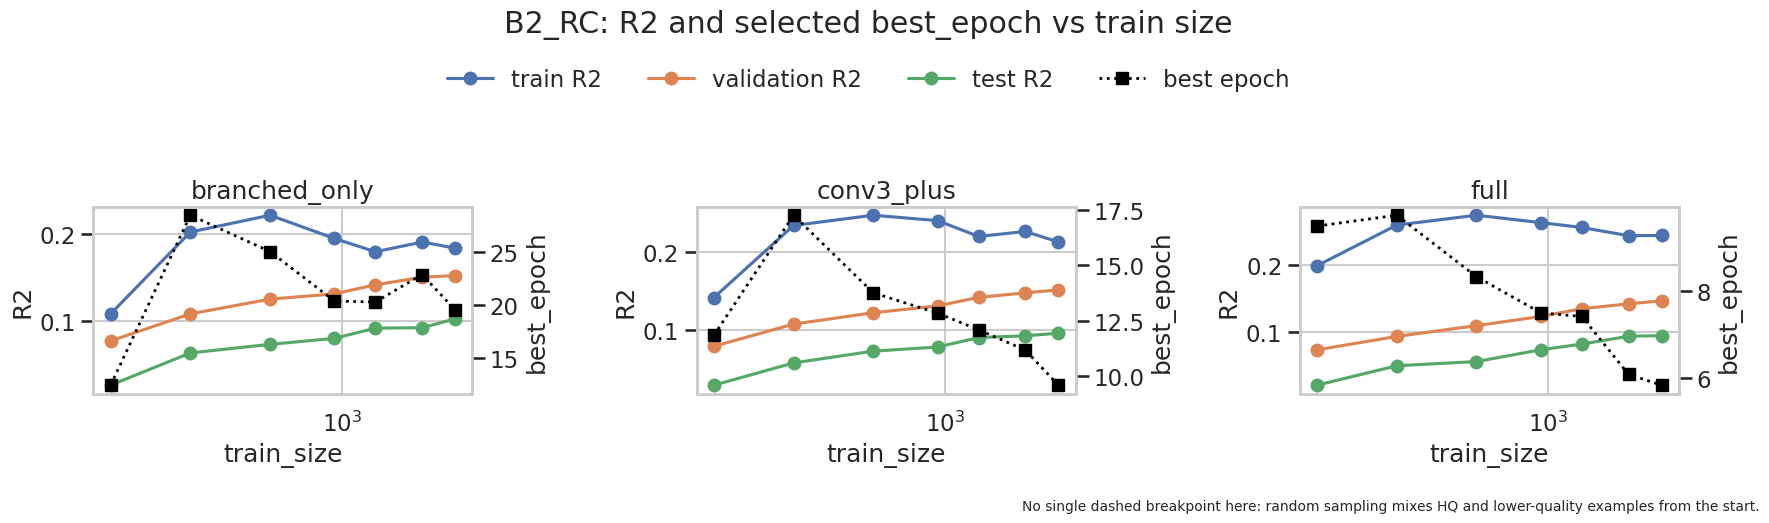

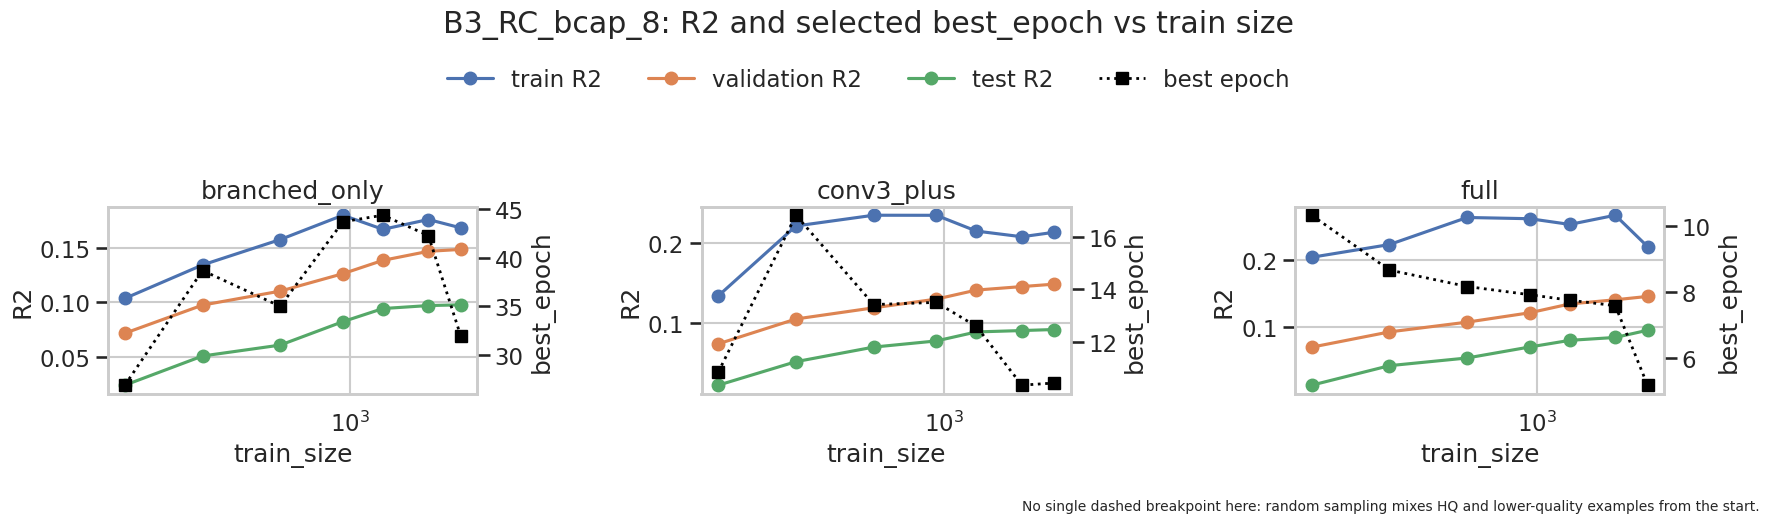

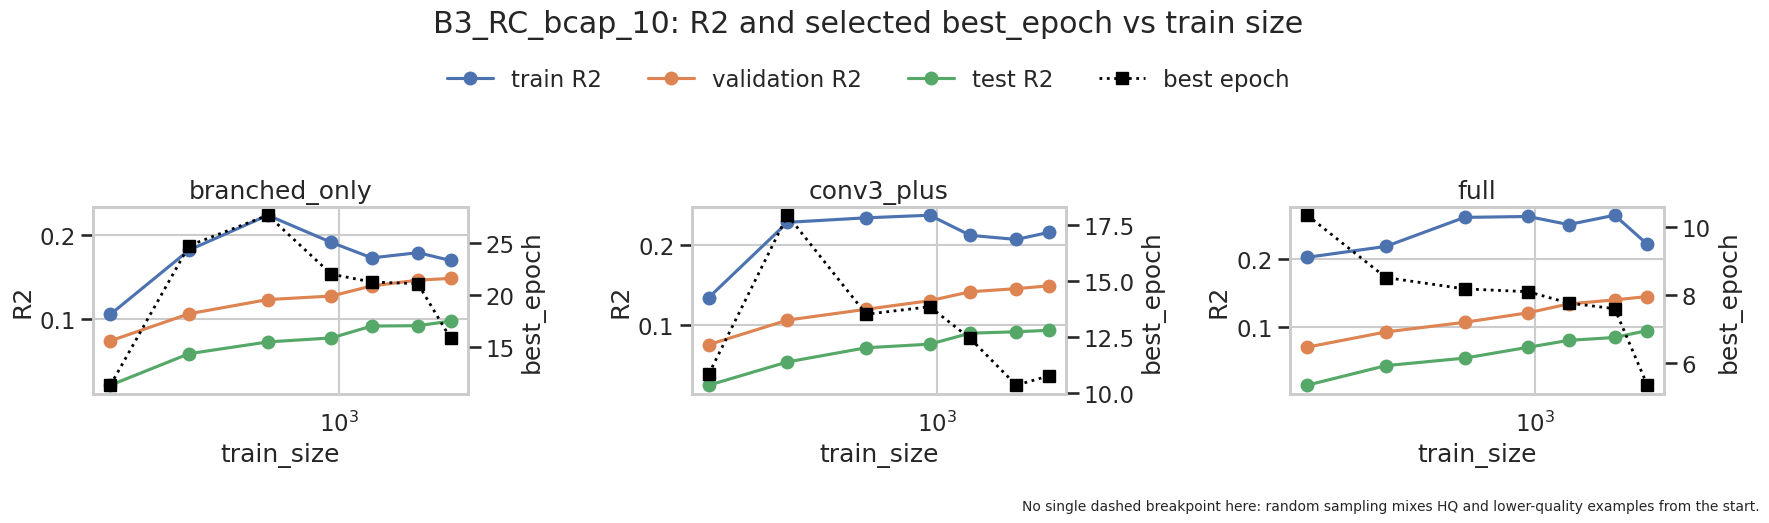

In [6]:
plot_dual_axis_curves(best_runs)

,setting_label,unfreeze_scope,test_r2_mean,test_r2_sd,val_r2_mean,best_epoch_mean
0,B2_RC,branched_only,0.102447,0.024798,0.152174,19.500000
3,B3_RC_bcap_10,branched_only,0.097935,0.019344,0.148514,15.833333
6,B3_RC_bcap_8,branched_only,0.097810,0.018400,0.148532,32.000000
1,B2_RC,conv3_plus,0.095621,0.028937,0.151027,9.583333
4,B3_RC_bcap_10,conv3_plus,0.092737,0.022695,0.148976,10.750000
7,B3_RC_bcap_8,conv3_plus,0.092362,0.024073,0.148762,10.416667
8,B3_RC_bcap_8,full,0.095655,0.022999,0.145563,5.166667
5,B3_RC_bcap_10,full,0.095397,0.022755,0.145472,5.333333
2,B2_RC,full,0.095254,0.028459,0.146731,5.833333


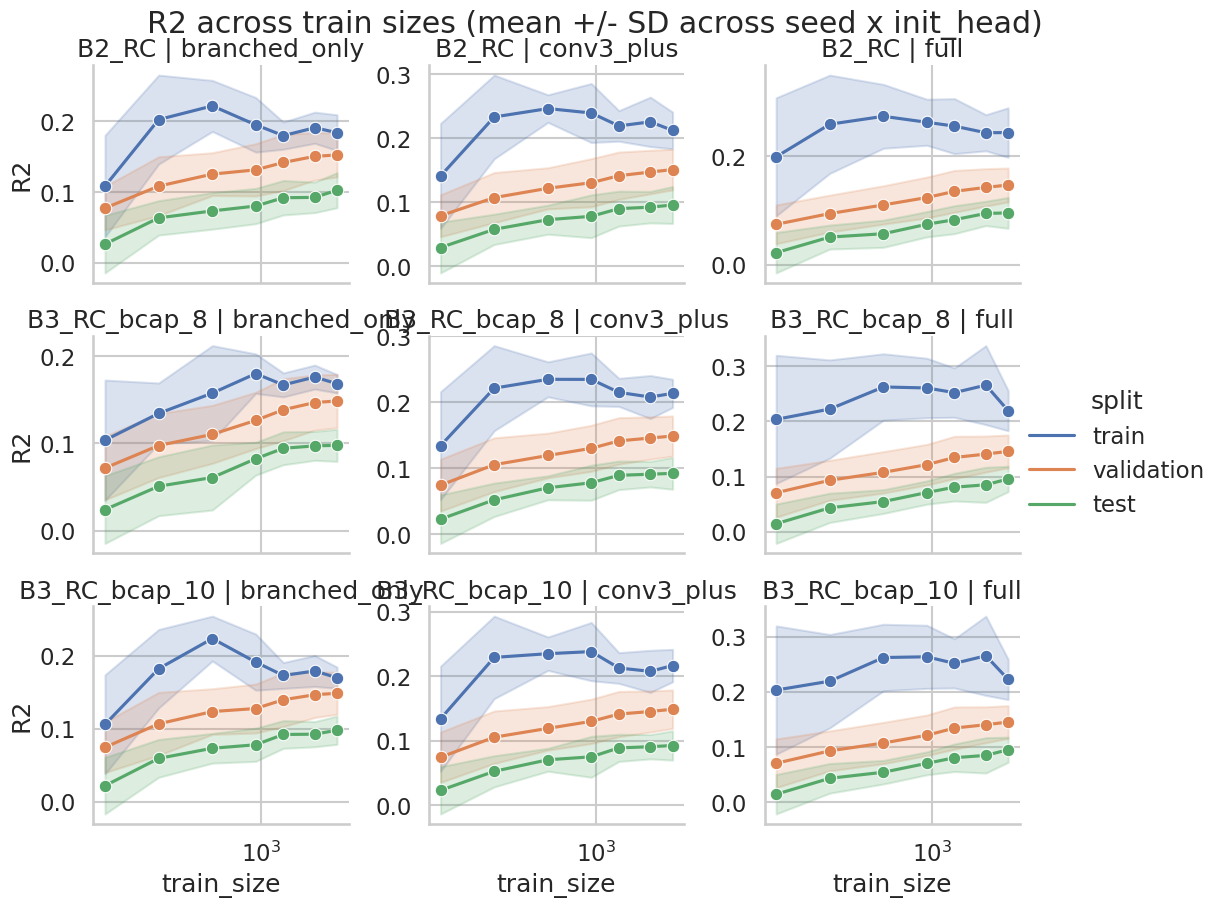

In [7]:
largest_size = int(best_runs["train_size"].max())
topline = (
    best_runs.loc[best_runs["train_size"] == largest_size]
    .groupby(["setting_label", "unfreeze_scope"], dropna=False)
    .agg(
        test_r2_mean=("test_r2", "mean"),
        test_r2_sd=("test_r2", "std"),
        val_r2_mean=("val_r2", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .reset_index()
    .sort_values(["unfreeze_scope", "test_r2_mean"], ascending=[True, False])
)
display(topline)

plot_split_metric_curves(best_runs, "r2", "R2")

,train_size,mean_train_hq_fraction,sd_train_hq_fraction,min_train_hq_fraction,max_train_hq_fraction,mean_train_hq_count,mean_train_lower_quality_count
0,134,0.309701,0.042870,0.253731,0.343284,41.50,92.50
1,268,0.307836,0.016265,0.283582,0.317164,82.50,185.50
2,536,0.312034,0.014799,0.292910,0.324627,167.25,368.75
3,938,0.313966,0.002219,0.311301,0.316631,294.50,643.50
4,1340,0.314739,0.007271,0.308955,0.325373,421.75,918.25
5,2011,0.316012,0.003841,0.313774,0.321730,635.50,1375.50
6,2681,0.318072,0.003214,0.314435,0.322268,852.75,1828.25


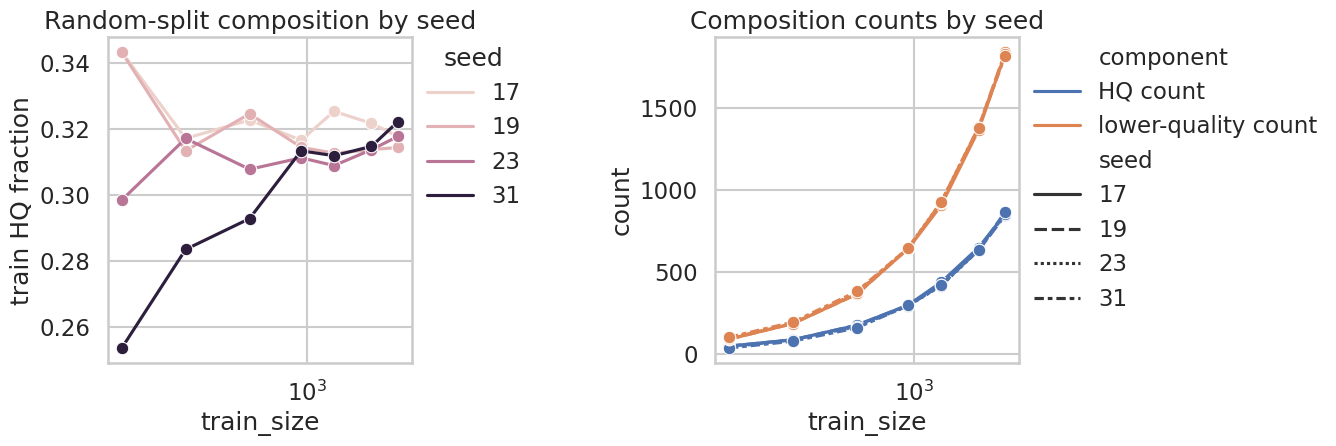

In [8]:
composition_frame = (
    runs[
        [
            "seed",
            "split_seed_effective",
            "train_size",
            "train_hq_fraction",
            "train_hq_count",
            "train_lower_quality_count",
            "train_pool_eligible_size",
        ]
    ]
    .drop_duplicates()
    .sort_values(["train_size", "seed"])
)

composition_summary = (
    composition_frame.groupby("train_size", dropna=False)
    .agg(
        mean_train_hq_fraction=("train_hq_fraction", "mean"),
        sd_train_hq_fraction=("train_hq_fraction", "std"),
        min_train_hq_fraction=("train_hq_fraction", "min"),
        max_train_hq_fraction=("train_hq_fraction", "max"),
        mean_train_hq_count=("train_hq_count", "mean"),
        mean_train_lower_quality_count=("train_lower_quality_count", "mean"),
    )
    .reset_index()
)
display(composition_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharex=True)

sns.lineplot(
    data=composition_frame,
    x="train_size",
    y="train_hq_fraction",
    hue="seed",
    marker="o",
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_xlabel("train_size")
axes[0].set_ylabel("train HQ fraction")
axes[0].set_title("Random-split composition by seed")
axes[0].legend(
    title="seed",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)

count_plot_df = composition_frame.melt(
    id_vars=["seed", "train_size"],
    value_vars=["train_hq_count", "train_lower_quality_count"],
    var_name="component",
    value_name="count",
).copy()
count_plot_df["component"] = count_plot_df["component"].map(
    {
        "train_hq_count": "HQ count",
        "train_lower_quality_count": "lower-quality count",
    }
)

sns.lineplot(
    data=count_plot_df,
    x="train_size",
    y="count",
    hue="component",
    style="seed",
    marker="o",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_xlabel("train_size")
axes[1].set_ylabel("count")
axes[1].set_title("Composition counts by seed")
axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
    frameon=False,
)

fig.tight_layout(rect=[0, 0, 0.86, 1], w_pad=3.0)
plt.show()

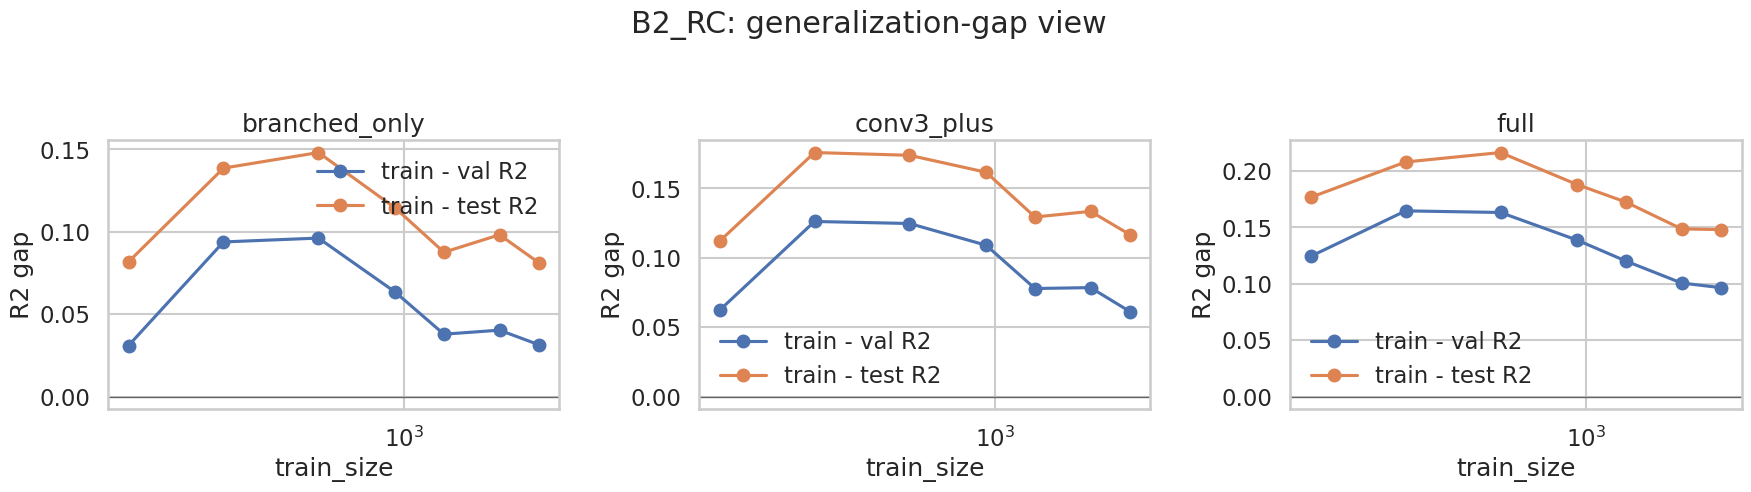

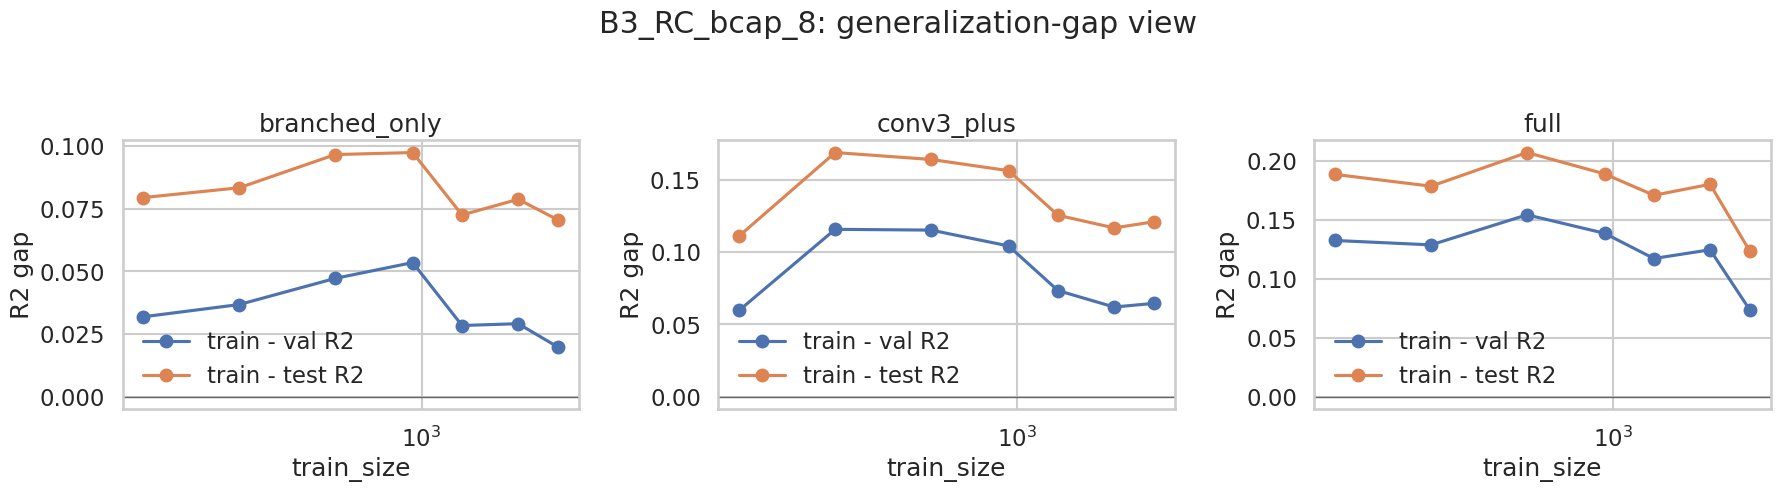

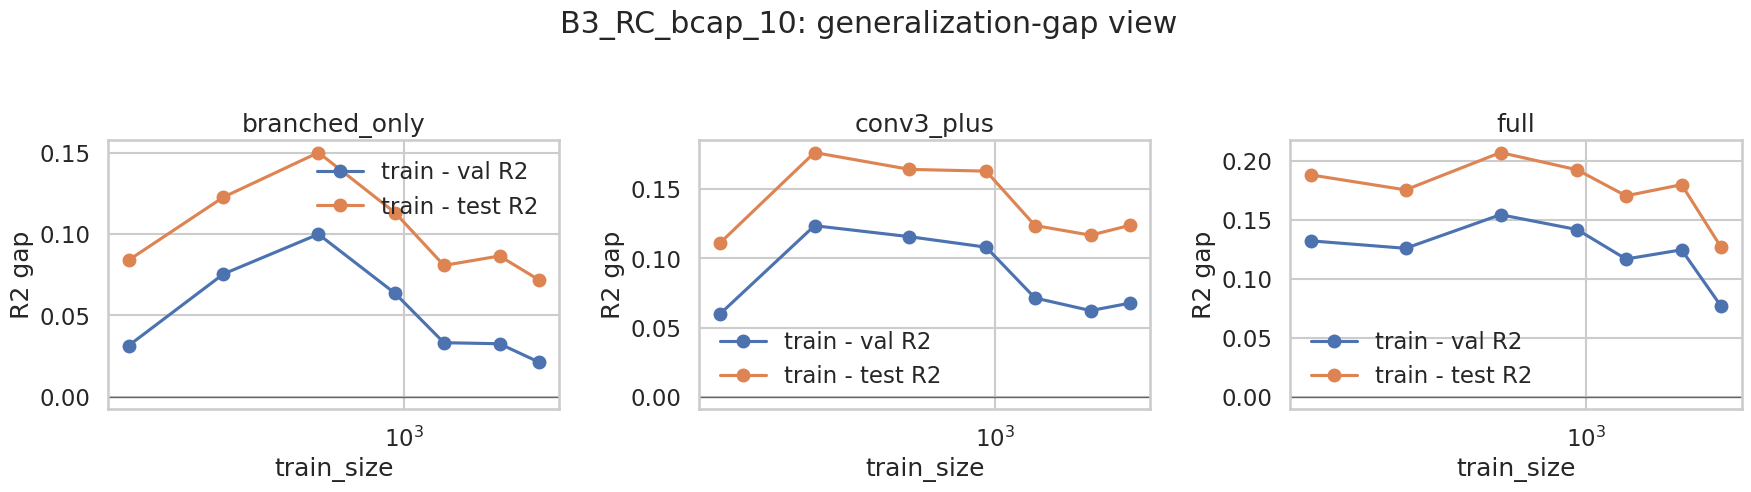

Text(0.5, 0.98, 'Per-seed best_epoch trajectories at the selected HPO')

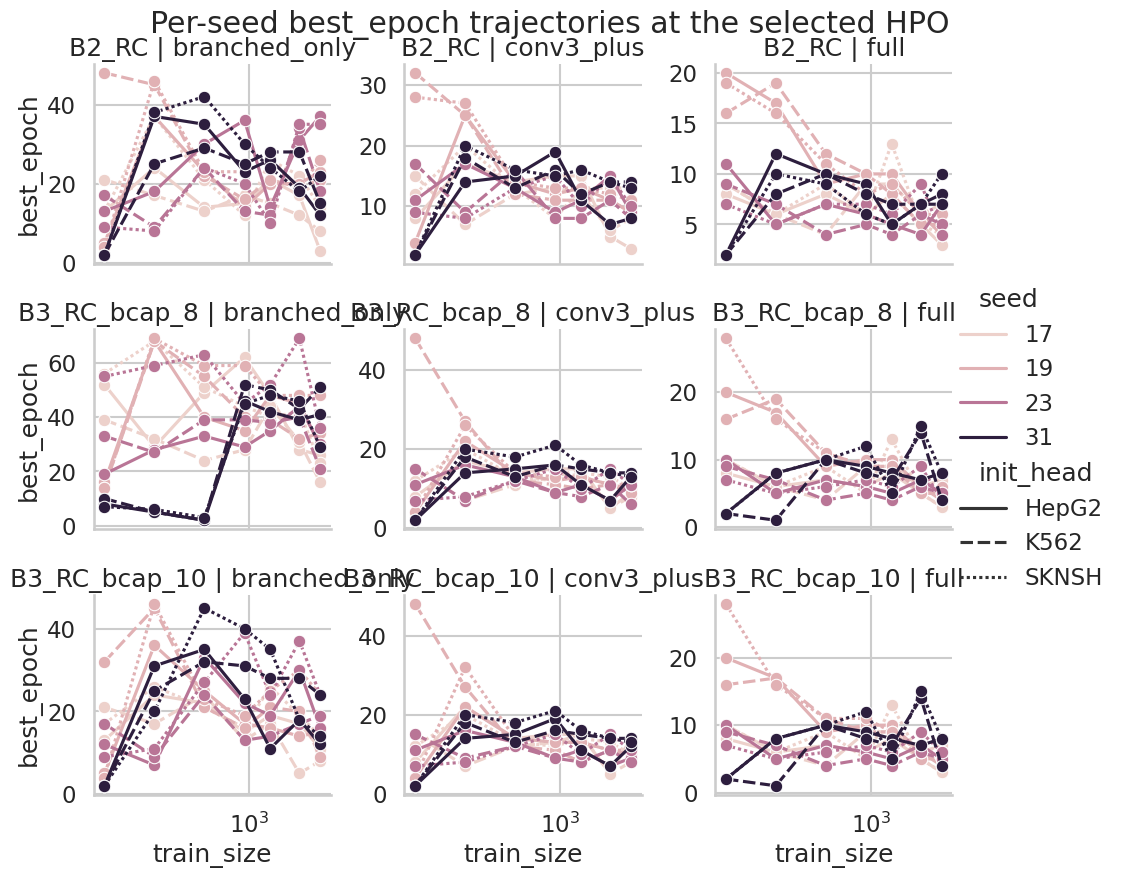

In [9]:
gap_df = (
    best_runs.groupby(["setting_label", "unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_r2_mean=("train_r2", "mean"),
        val_r2_mean=("val_r2", "mean"),
        test_r2_mean=("test_r2", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .reset_index()
)
gap_df["train_val_r2_gap"] = gap_df["train_r2_mean"] - gap_df["val_r2_mean"]
gap_df["train_test_r2_gap"] = gap_df["train_r2_mean"] - gap_df["test_r2_mean"]

for setting_label in setting_order:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    setting_df = gap_df[gap_df["setting_label"] == setting_label].copy()

    for ax, scope in zip(axes, scope_order):
        sub = setting_df[setting_df["unfreeze_scope"] == scope].sort_values("train_size")
        if sub.empty:
            ax.set_visible(False)
            continue

        ax.plot(sub["train_size"], sub["train_val_r2_gap"], marker="o", label="train - val R2")
        ax.plot(sub["train_size"], sub["train_test_r2_gap"], marker="o", label="train - test R2")
        ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel("train_size")
        ax.set_ylabel("R2 gap")
        ax.set_title(scope)
        ax.legend(frameon=False)

    fig.suptitle(f"{setting_label}: generalization-gap view", y=1.04)
    fig.tight_layout()
    plt.show()

best_epoch_grid = sns.relplot(
    data=best_runs,
    x="train_size",
    y="best_epoch",
    hue="seed",
    style="init_head",
    row="setting_label",
    col="unfreeze_scope",
    row_order=setting_order,
    col_order=scope_order,
    kind="line",
    marker="o",
    height=3.0,
    aspect=1.1,
    facet_kws={"sharex": True, "sharey": False},
)
best_epoch_grid.set(xscale="log")
best_epoch_grid.set_axis_labels("train_size", "best_epoch")
best_epoch_grid.set_titles("{row_name} | {col_name}")
best_epoch_grid.fig.subplots_adjust(top=0.92)
best_epoch_grid.fig.suptitle("Per-seed best_epoch trajectories at the selected HPO")

,setting_label,unfreeze_scope,best_epoch_mean,best_epoch_sd,test_r2_mean,val_r2_mean
0,B2_RC,branched_only,19.500000,10.104005,0.102447,0.152174
1,B2_RC,conv3_plus,9.583333,2.968267,0.095621,0.151027
2,B2_RC,full,5.833333,2.037527,0.095254,0.146731
3,B3_RC_bcap_10,branched_only,15.833333,5.749835,0.097935,0.148514
4,B3_RC_bcap_10,conv3_plus,10.750000,2.137331,0.092737,0.148976
5,B3_RC_bcap_10,full,5.333333,1.723281,0.095397,0.145472
6,B3_RC_bcap_8,branched_only,32.000000,10.591592,0.097810,0.148532
7,B3_RC_bcap_8,conv3_plus,10.416667,2.274696,0.092362,0.148762
8,B3_RC_bcap_8,full,5.166667,1.749459,0.095655,0.145563


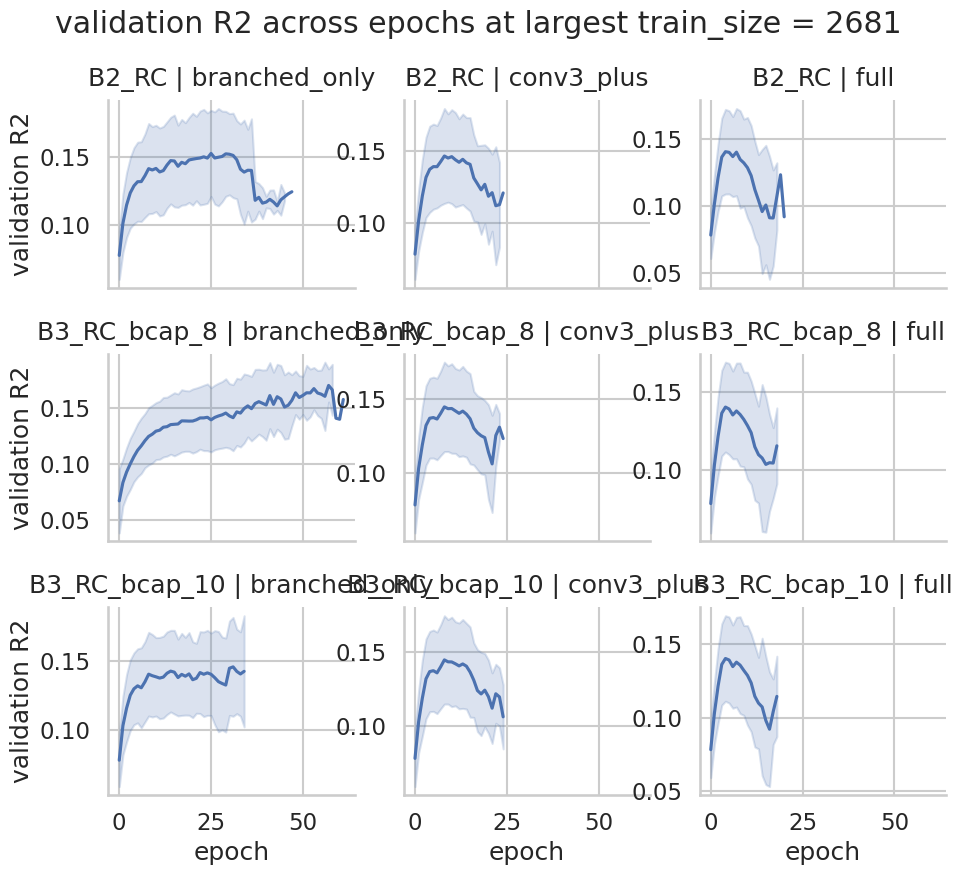

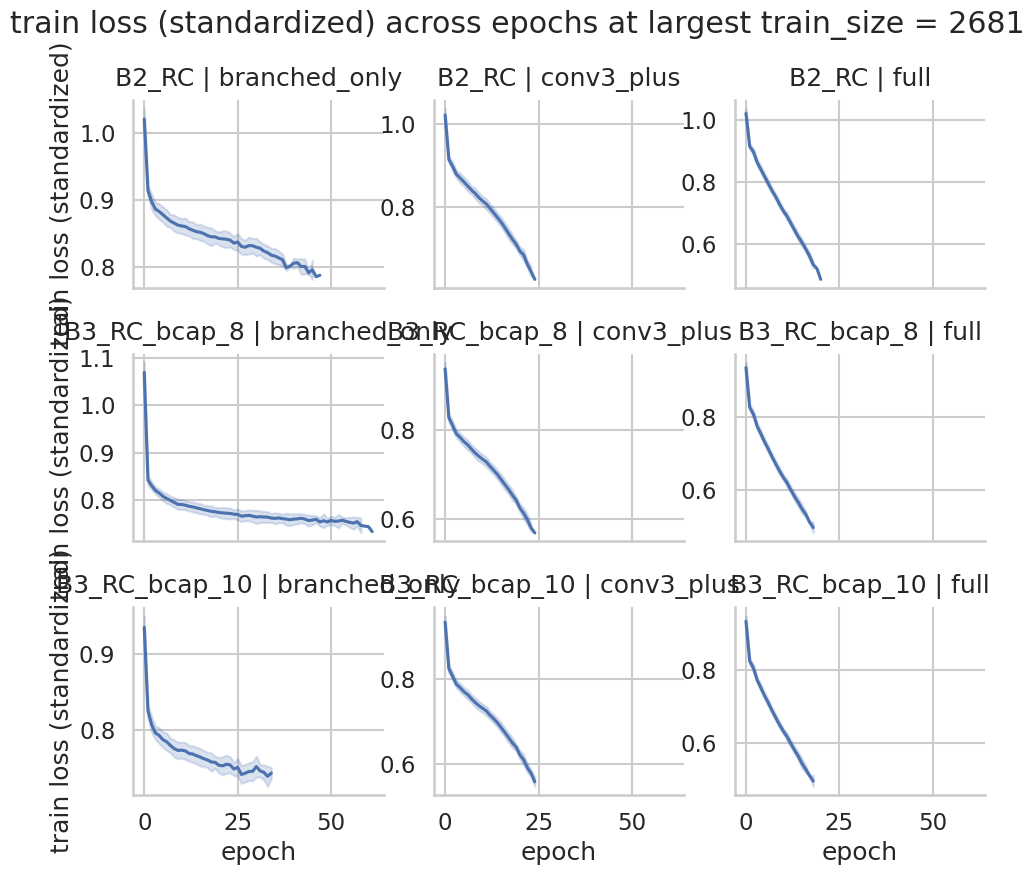

In [10]:
largest_train_size = int(best_histories["train_size"].max())
largest_train_epoch_summary = (
    best_runs.loc[best_runs["train_size"] == largest_train_size]
    .groupby(["setting_label", "unfreeze_scope"], dropna=False)
    .agg(
        best_epoch_mean=("best_epoch", "mean"),
        best_epoch_sd=("best_epoch", "std"),
        test_r2_mean=("test_r2", "mean"),
        val_r2_mean=("val_r2", "mean"),
    )
    .reset_index()
)
display(largest_train_epoch_summary)

plot_epoch_metric_at_largest_train_size(best_histories, "val_r2", "validation R2")
plot_epoch_metric_at_largest_train_size(best_histories, "train_loss_standardized", "train loss (standardized)")

,b3_setting_label,unfreeze_scope,train_size,mean_delta_test_r2,sd_delta_test_r2,mean_delta_val_r2,n_pairs
0,B3_RC_bcap_10,branched_only,134,-0.004393,0.006797,-0.002661,12
1,B3_RC_bcap_10,branched_only,268,-0.004046,0.008380,-0.001560,12
2,B3_RC_bcap_10,branched_only,536,-0.000014,0.007296,-0.001693,12
3,B3_RC_bcap_10,branched_only,938,-0.002109,0.006919,-0.003573,12
4,B3_RC_bcap_10,branched_only,1340,0.000269,0.007137,-0.001927,12
5,B3_RC_bcap_10,branched_only,2011,0.000129,0.008797,-0.003767,12
6,B3_RC_bcap_10,branched_only,2681,-0.004512,0.006775,-0.003660,12
7,B3_RC_bcap_10,conv3_plus,134,-0.005781,0.007091,-0.004219,12
8,B3_RC_bcap_10,conv3_plus,268,-0.004814,0.005437,-0.001571,12
9,B3_RC_bcap_10,conv3_plus,536,-0.001988,0.008854,-0.002452,12


,setting_label,unfreeze_scope,train_size,test_r2_mean,val_r2_mean,delta_size,delta_metric,gain_per_sample,gain_per_1000_samples
0,B2_RC,branched_only,134,0.026398,0.077217,NaN,NaN,NaN,NaN
1,B2_RC,branched_only,268,0.063418,0.108205,134.0,0.037020,0.000276,0.276272
2,B2_RC,branched_only,536,0.073242,0.125147,268.0,0.009824,0.000037,0.036657
3,B2_RC,branched_only,938,0.080121,0.131181,402.0,0.006879,0.000017,0.017111
4,B2_RC,branched_only,1340,0.091825,0.141560,402.0,0.011704,0.000029,0.029115
...,...,...,...,...,...,...,...,...,...
58,B3_RC_bcap_8,full,536,0.054752,0.107625,268.0,0.011352,0.000042,0.042359
59,B3_RC_bcap_8,full,938,0.071018,0.121477,402.0,0.016266,0.000040,0.040463
60,B3_RC_bcap_8,full,1340,0.080777,0.134483,402.0,0.009759,0.000024,0.024276
61,B3_RC_bcap_8,full,2011,0.085044,0.140622,671.0,0.004267,0.000006,0.006359


Text(0.5, 0.98, "Tail-slope view for the '+1000 samples' question")

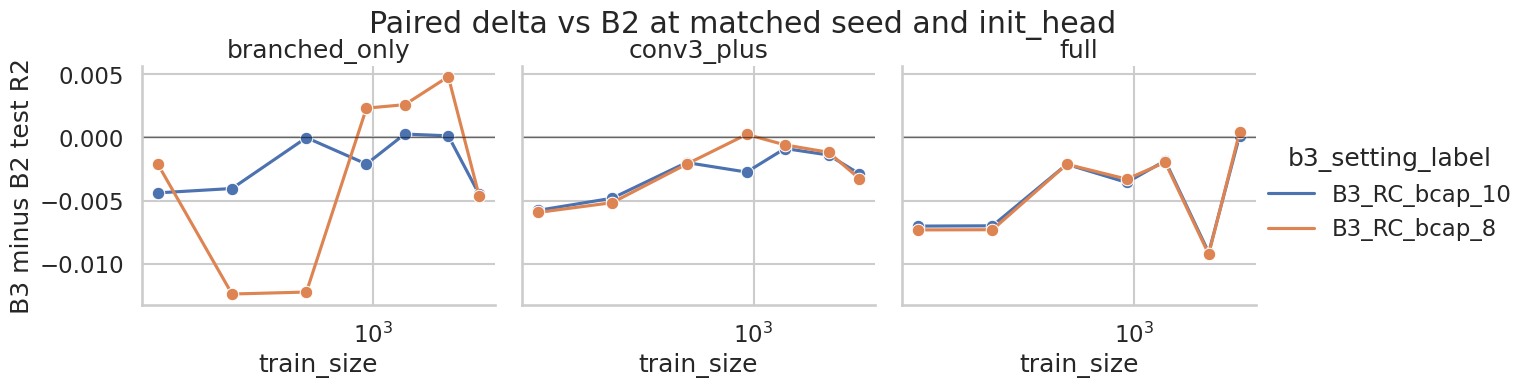

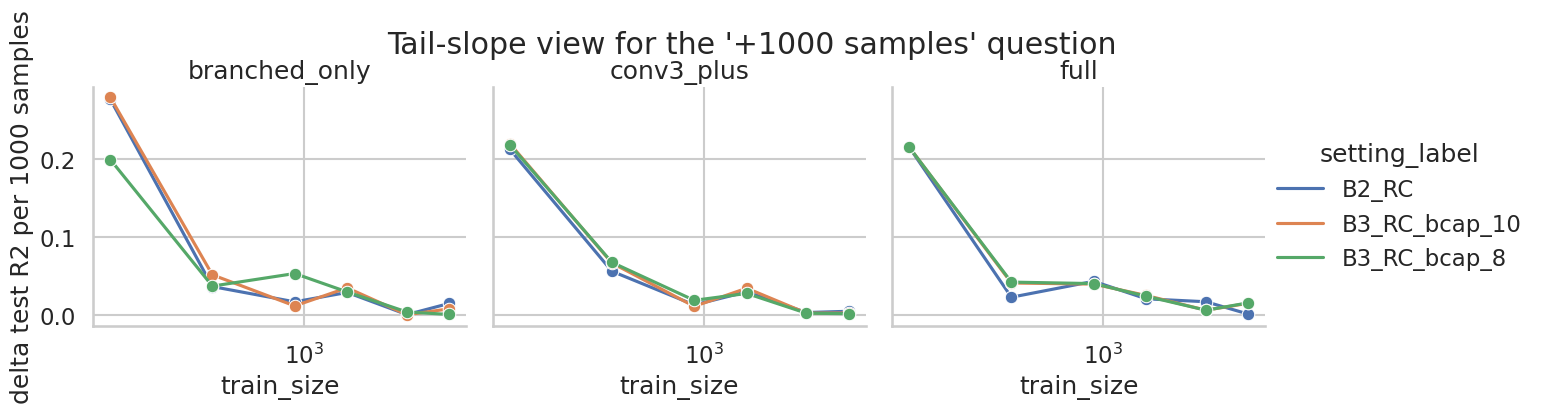

In [11]:
match_cols = ["seed", "init_head", "unfreeze_scope", "train_size"]

b2_frame = (
    best_runs.loc[best_runs["setting"] == "B2_with_RC", match_cols + ["test_r2", "val_r2"]]
    .rename(columns={"test_r2": "test_r2_b2", "val_r2": "val_r2_b2"})
)
b3_frame = (
    best_runs.loc[
        best_runs["setting"].isin(["B3_with_RC_weighted_bcap_8", "B3_with_RC_weighted_bcap_10"]),
        match_cols + ["setting_label", "test_r2", "val_r2"],
    ]
    .rename(
        columns={
            "setting_label": "b3_setting_label",
            "test_r2": "test_r2_b3",
            "val_r2": "val_r2_b3",
        }
    )
)
paired_delta = b3_frame.merge(b2_frame, on=match_cols, how="inner")
paired_delta["delta_test_r2"] = paired_delta["test_r2_b3"] - paired_delta["test_r2_b2"]
paired_delta["delta_val_r2"] = paired_delta["val_r2_b3"] - paired_delta["val_r2_b2"]

paired_delta_summary = (
    paired_delta.groupby(["b3_setting_label", "unfreeze_scope", "train_size"], dropna=False)
    .agg(
        mean_delta_test_r2=("delta_test_r2", "mean"),
        sd_delta_test_r2=("delta_test_r2", "std"),
        mean_delta_val_r2=("delta_val_r2", "mean"),
        n_pairs=("delta_test_r2", "size"),
    )
    .reset_index()
)
display(paired_delta_summary)

paired_delta_grid = sns.relplot(
    data=paired_delta_summary,
    x="train_size",
    y="mean_delta_test_r2",
    hue="b3_setting_label",
    col="unfreeze_scope",
    col_order=scope_order,
    kind="line",
    marker="o",
    height=4.0,
    aspect=1.1,
)
paired_delta_grid.set(xscale="log")
paired_delta_grid.set_axis_labels("train_size", "B3 minus B2 test R2")
paired_delta_grid.set_titles("{col_name}")
for ax in paired_delta_grid.axes.flat:
    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
paired_delta_grid.fig.subplots_adjust(top=0.84)
paired_delta_grid.fig.suptitle("Paired delta vs B2 at matched seed and init_head")

marginal_gain_df = (
    best_runs.groupby(["setting_label", "unfreeze_scope", "train_size"], dropna=False)
    .agg(test_r2_mean=("test_r2", "mean"), val_r2_mean=("val_r2", "mean"))
    .reset_index()
)
marginal_gain_df = add_marginal_gain_columns(
    marginal_gain_df,
    metric_col="test_r2_mean",
    group_cols=["setting_label", "unfreeze_scope"],
)
display(marginal_gain_df)

marginal_gain_grid = sns.relplot(
    data=marginal_gain_df.dropna(subset=["gain_per_1000_samples"]),
    x="train_size",
    y="gain_per_1000_samples",
    hue="setting_label",
    col="unfreeze_scope",
    col_order=scope_order,
    kind="line",
    marker="o",
    height=4.0,
    aspect=1.1,
)
marginal_gain_grid.set(xscale="log")
marginal_gain_grid.set_axis_labels("train_size", "delta test R2 per 1000 samples")
marginal_gain_grid.set_titles("{col_name}")
marginal_gain_grid.fig.subplots_adjust(top=0.84)
marginal_gain_grid.fig.suptitle("Tail-slope view for the '+1000 samples' question")

## Notes

- Unlike the earlier HQ-first notebook, there is no single quality-transition train size to mark with a dashed line. With `train_sampling_mode = random`, the HQ fraction already varies by seed at the smallest train sizes.
- The most direct readouts for the robustness question are the top-end test `R2`, the paired `B3 - B2` delta curves, and whether `best_epoch` stays stable or becomes erratic as train size changes.
- The history file still does not contain per-epoch test metrics, so the epoch-level section focuses on `validation R2` and `train_loss_standardized`.
- If we want an even sharper follow-up, the next natural comparison is against the earlier HQ-first notebook at matched train sizes and matched selected HPO.